# -*- coding: utf-8 -*-

## Two population decision making model

References:
Wong, Kong-Fatt, and Xiao-Jing Wang.
"A recurrent network mechanism of time integration in perceptual decisions."
The Journal of neuroscience 26.4 (2006): 1314-1328.

@author: guangyu robert yang

In [6]:
# Python 3.13 compatible imports (no __future__ needed in Python 3)
import numpy as np
import matplotlib
import os
from __future__ import division
import matplotlib.pyplot as plt

In [21]:
# Define transfer function + run + inline plot



def F(I, a=270.0, b=108.0, d=0.154):
    """Transfer function F(I) for vector I."""
    return (a * I - b) / (1.0 - np.exp(-d * (a * I - b)))


modelparams = dict(
    gE=0.2609,
    gI=-0.0497,  # cross-inhibition strength [nA]
    I0=0.3255,  # background current [nA]
    tauS=0.1,  # Synaptic time constant [sec]
    gamma=0.641,  # Saturation factor for gating variable
    tau0=0.002,  # Noise time constant [sec]
    sigma=0.02,  # Noise magnitude [nA]
    mu0=20.0,  # Stimulus firing rate [Hz]
    Jext=0.52,  # Stimulus input strength [pA/Hz]
    Ttotal=2.0,  # Total duration of simulation [s]
    Tstim_on=0.1,  # Time of stimulus onset
    Tstim_off=1.0,  # Time of stimulus offset
    dt=0.5 / 1000,  # Simulation time step
    record_dt=5 / 1000,
)
# Make plotting safe in headless runs (e.g. when running as a script)
def _in_ipython():
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False

if (not _in_ipython()) and (not os.environ.get("DISPLAY")):
    matplotlib.use("Agg")


class Model:
    def __init__(self, modelparams):
        self.params = modelparams.copy()

    def run(self, n_trial=1, coh=0):
        p = self.params

        NT = int(p["Ttotal"] / p["dt"])
        t_plot = np.arange(NT) * p["dt"]
        t_stim = (t_plot > p["Tstim_on"]) * (t_plot < p["Tstim_off"])

        mean_stim = np.ones(NT) * p["mu0"] * p["Jext"] / 1000  # [nA]
        diff_stim = p["Jext"] * p["mu0"] * coh / 100.0 * 2
        Istim1_plot = (mean_stim + diff_stim / 2 / 1000) * t_stim
        Istim2_plot = (mean_stim - diff_stim / 2 / 1000) * t_stim

        S1 = 0.1 * np.ones(n_trial)
        S2 = 0.1 * np.ones(n_trial)
        Ieta1 = np.zeros(n_trial)
        Ieta2 = np.zeros(n_trial)

        n_record = int(p["record_dt"] // p["dt"])
        i_record = 0
        N_record = int(p["Ttotal"] / p["record_dt"])

        self.r1 = np.zeros((N_record, n_trial))
        self.r2 = np.zeros((N_record, n_trial))
        self.t = np.zeros(N_record)
        self.I1 = np.zeros(N_record)
        self.I2 = np.zeros(N_record)

        # Use global F(t) defined in the original notebook cell.
        for i_t in range(NT):
            Istim1 = Istim1_plot[i_t]
            Istim2 = Istim2_plot[i_t]

            Isyn1 = p["gE"] * S1 + p["gI"] * S2 + Istim1 + Ieta1
            Isyn2 = p["gE"] * S2 + p["gI"] * S1 + Istim2 + Ieta2

            r1 = F(Isyn1)
            r2 = F(Isyn2)

            S1_next = S1 + p["dt"] * (-S1 / p["tauS"] + (1 - S1) * p["gamma"] * r1)
            S2_next = S2 + p["dt"] * (-S2 / p["tauS"] + (1 - S2) * p["gamma"] * r2)

            Ieta1_next = (
                Ieta1
                + (p["dt"] / p["tau0"]) * (p["I0"] - Ieta1)
                + np.sqrt(p["dt"] / p["tau0"]) * p["sigma"] * np.random.randn(n_trial)
            )
            Ieta2_next = (
                Ieta2
                + (p["dt"] / p["tau0"]) * (p["I0"] - Ieta2)
                + np.sqrt(p["dt"] / p["tau0"]) * p["sigma"] * np.random.randn(n_trial)
            )

            S1 = S1_next
            S2 = S2_next
            Ieta1 = Ieta1_next
            Ieta2 = Ieta2_next

            if i_t % n_record == 1:
                self.r1[i_record] = r1
                self.r2[i_record] = r2
                self.I1[i_record] = Istim1
                self.I2[i_record] = Istim2
                self.t[i_record] = i_t * p["dt"]
                i_record += 1


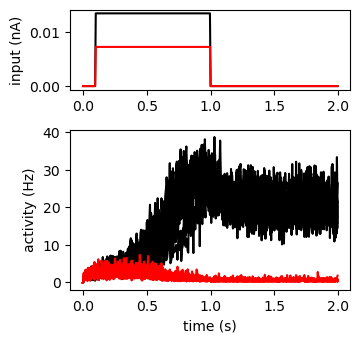

In [22]:



model = Model(modelparams)
model.run(coh=30, n_trial=10)

fig = plt.figure(figsize=(4, 4))
ax = fig.add_axes([0.2, 0.7, 0.7, 0.2])
plt.plot(model.t, model.I1, 'black')
plt.plot(model.t, model.I2, 'red')
plt.ylabel('input (nA)')

ax = fig.add_axes([0.2, 0.2, 0.7, 0.4])
plt.plot(model.t, model.r1, 'black')
plt.plot(model.t, model.r2, 'red')
plt.xlabel('time (s)')
plt.ylabel('activity (Hz)')

plt.show()